In [77]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score 
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/titanik.csv', delimiter = ';')

In [78]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund; Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,Cumings; Mrs. John Bradley (Florence Briggs Th...,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,Heikkinen; Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,Futrelle; Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,Allen; Mr. William Henry,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Montvila; Rev. Juozas,male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,Graham; Miss. Margaret Edith,female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston; Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,Behr; Mr. Karl Howell,male,26.0,0,0,111369,30.0000,C148,C


In [79]:
df.info() # Смотрим, в каких столбцах есть пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [80]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [81]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,3,681,147,3
top,Dooley; Mr. Patrick,male,347082,G6,S
freq,1,574,7,4,644


In [82]:
# Переведем "Sex": {'male', 'female'} в числовой: {1, 0}

df['Sex'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)

In [83]:
# Удалим PassengerId (так как он не несет полезной информации), 
# Name(в рамках этого скринкаста также не будем его использовать), 
# Ticket (аналог id пассажира - у каждого билета уникальный номер)

df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

In [84]:
# Удалим Cabin, так как в нем очень много пропущенных значений (первая стратегия)

df.drop(['Cabin'], axis = 1, inplace = True)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      889 non-null    float64
 1   Sex         889 non-null    float64
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    float64
 4   Parch       889 non-null    float64
 5   Fare        889 non-null    float64
 6   Embarked_Q  889 non-null    float64
 7   Embarked_S  889 non-null    float64
dtypes: float64(8)
memory usage: 55.7 KB


In [86]:
# В столбце Embarked всего два пропущенных значения - выкинем строки с этими значениями (вторая стратегия)

df = df[df['Embarked'].notna()]

In [87]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [88]:
# Столбец Embarked категориальный - закодируем его с помощью OHE

df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True, dtype = int)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


In [89]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


In [90]:
# Сделаем нормализацию (масштабирование) данных 
# NB: так как есть пропуски, то можно сделать масштабирование по всем данным (без деления на train, test)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X)

X = pd.DataFrame(scaler.transform(X), columns = X.columns)

In [97]:
# Заполним пропуски в столбце Age средним значением, но можно еще заполнять медианой (третья стратегия)

updated_X = X.copy()
updated_X['Age'] = updated_X['Age'].fillna(updated_X['Age'].mean())

In [98]:
updated_X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1.0,1.0,0.271174,0.125,0.000000,0.014151,0.0,1.0
1,0.0,0.0,0.472229,0.125,0.000000,0.139136,0.0,0.0
2,1.0,0.0,0.321438,0.000,0.000000,0.015469,0.0,1.0
3,0.0,0.0,0.434531,0.125,0.000000,0.103644,0.0,1.0
4,1.0,1.0,0.434531,0.000,0.000000,0.015713,0.0,1.0
...,...,...,...,...,...,...,...,...
884,0.5,1.0,0.334004,0.000,0.000000,0.025374,0.0,1.0
885,0.0,0.0,0.233476,0.000,0.000000,0.058556,0.0,1.0
886,1.0,0.0,0.367204,0.125,0.333333,0.045771,0.0,1.0
887,0.0,1.0,0.321438,0.000,0.000000,0.058556,0.0,0.0


In [102]:
# Оценим качество модели при помощи кросс-валидации

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits = 3, random_state = 42, shuffle = True)

cross_val_score(LogisticRegression(), updated_X, y, cv = cv).mean()

np.float64(0.7997732581065914)

In [104]:
# Используем МО для предсказания пропущенных значений (четвертая стратегия)

from sklearn.linear_model import LinearRegression

X_numeric = X.copy()

test_X = X_numeric[X_numeric['Age'].isnull() == True]
train_X = X_numeric[X_numeric['Age'].isnull() == False]
z = train_X['Age']

train_X.drop(['Age'], axis = 1, inplace = True)
test_X.drop(['Age'], axis = 1, inplace = True)

In [105]:
lr = LinearRegression()

lr.fit(train_X, z)

pred = lr.predict(test_X)

In [108]:
# Создадим еще 1 копию таблицы признаков и заполним пропуски предсказаниями линейной регрессии

updated_X2 = X.copy()

indices = test_X.index.to_numpy()

updated_X2.loc[indices, 'Age'] = pred

In [109]:
updated_X2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      889 non-null    float64
 1   Sex         889 non-null    float64
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    float64
 4   Parch       889 non-null    float64
 5   Fare        889 non-null    float64
 6   Embarked_Q  889 non-null    float64
 7   Embarked_S  889 non-null    float64
dtypes: float64(8)
memory usage: 55.7 KB


In [110]:
cross_val_score(LogisticRegression(), updated_X2, y, cv = cv).mean()

np.float64(0.7975210058543393)

# Задача бинарной классификации

In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [111]:
data = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/bike_buyers_clean.csv')

In [112]:
data.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes


In [113]:
# Проверим типы колонок в датасете

data.dtypes

ID                   int64
Marital Status      object
Gender              object
Income               int64
Children             int64
Education           object
Occupation          object
Home Owner          object
Cars                 int64
Commute Distance    object
Region              object
Age                  int64
Purchased Bike      object
dtype: object

In [114]:
# Удалим колонку с ID

X = data.iloc[:,:-1]
X.drop(columns = 'ID', inplace = True)

# Закодируем целевую переменную: 1 - купил велик, 0 - не купил

y = data['Purchased Bike'].map({'Yes' : 1, 'No' : 0})

In [116]:
# Поделим признаки на числовые и категориальные

num_cols = X.columns[X.dtypes == 'int64'].tolist()
cat_cols = X.columns[X.dtypes == 'object']

print(f"We have {len(num_cols)} numeric columns: {', '.join(num_cols)}")
print(f"And {len(cat_cols)} categorical columns: {', '.join(cat_cols)}")

We have 4 numeric columns: Income, Children, Cars, Age
And 7 categorical columns: Marital Status, Gender, Education, Occupation, Home Owner, Commute Distance, Region


In [117]:
# Поделим категориальные переменные на 
# бинарные,
# ординальные (порядковые),
# все остальные колонки (больше 2 значений и не порядковые)

binary_cols = cat_cols[X[cat_cols].nunique() == 2].tolist()
ordinal_cols = ['Commute Distance', 'Education']
cat_cols = cat_cols.difference(binary_cols + ordinal_cols).tolist()

In [122]:
# Библиотека, в которой много разных способов кодировки категориальных признаков
!pip install seaborn -q 

In [119]:
from category_encoders.ordinal import OrdinalEncoder # LabelEncoder - кодирование подряд идущими числами
from category_encoders.one_hot import OneHotEncoder # OneHotEncoding
from category_encoders.target_encoder import TargetEncoder # счетчики+сглаживание
from category_encoders.leave_one_out import LeaveOneOutEncoder # счетчики по LOO-кросс-валидации - число фолдов = числу объектов

In [124]:
# Ordinal - from categories to numbers

ord_enc = OrdinalEncoder()
ord_enc.fit_transform(X['Education'])

,Education
0,1
1,2
2,2
3,1
4,1
...,...
995,3
996,5
997,1
998,1


In [125]:
# OHE: from k categories to k dummy columns

one_hot_enc = OneHotEncoder()

one_hot_enc.fit_transform(X['Education'], drop = 'first')
# * fit -> определить количество новых столбцов (по кол-ву категорий)
# * transform -> создать новые столбцы
# * fit_transform = fit + transform

,Education_1,Education_2,Education_3,Education_4,Education_5
0,1,0,0,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
995,0,0,1,0,0
996,0,0,0,0,1
997,1,0,0,0,0
998,1,0,0,0,0


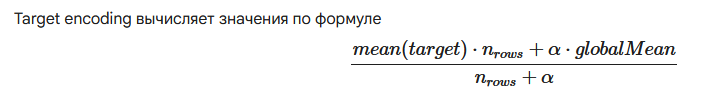

In [126]:
tgt_enc = TargetEncoder(smoothing=1)

# smoothing - это коэффициент сглаживания alpha, чем он больше, тем больше регуляризация

tgt_enc.fit_transform(X['Education'], y)

,Education
0,0.552288
1,0.449057
2,0.449057
3,0.552288
4,0.552288
...,...
995,0.441341
996,0.540230
997,0.552288
998,0.552288


In [127]:
loo_enc = LeaveOneOutEncoder(sigma=0.3)

loo_enc.fit_transform(X['Education'], y)

,Education
0,0.406026
1,0.566813
2,0.214108
3,0.250394
4,0.435179
...,...
995,0.536492
996,0.803836
997,0.477955
998,0.500084


In [128]:
# Энкодер можно применять сразу на весь датафрейм

tgt_enc = TargetEncoder(cols=['Education', 'Gender', 'Region'])
tgt_enc.fit_transform(X, y)

,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age
0,Married,0.486762,40000,1,0.552288,Skilled Manual,Yes,0,0-1 Miles,0.493333,42
1,Married,0.475442,30000,3,0.449057,Clerical,Yes,1,0-1 Miles,0.493333,43
2,Married,0.475442,80000,5,0.449057,Professional,No,2,2-5 Miles,0.493333,60
3,Single,0.475442,70000,0,0.552288,Professional,Yes,1,5-10 Miles,0.588542,41
4,Single,0.475442,30000,0,0.552288,Clerical,No,0,0-1 Miles,0.493333,36
...,...,...,...,...,...,...,...,...,...,...,...
995,Married,0.475442,60000,2,0.441341,Professional,Yes,2,2-5 Miles,0.433071,54
996,Single,0.475442,70000,4,0.540230,Professional,Yes,0,2-5 Miles,0.433071,35
997,Married,0.475442,60000,2,0.552288,Skilled Manual,Yes,0,0-1 Miles,0.433071,38
998,Single,0.475442,100000,3,0.552288,Management,No,3,1-2 Miles,0.433071,38


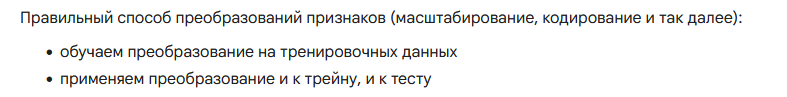

In [129]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=42)

In [130]:
tgt_enc = TargetEncoder(cols=['Education', 'Gender', 'Region'])

tgt_enc.fit(Xtrain, ytrain)

Xtrain_new = tgt_enc.transform(Xtrain)
Xtest_new = tgt_enc.transform(Xtest)

# Задача предсказания стоимости автомобилей по их различным характеристикам.

In [131]:
!pip uninstall -y category-encoders

!pip uninstall -y scikit-learn

!pip install category-encoders==2.5

!pip install scikit-learn==1.3.1

!pip install pandas==1.5.3

Found existing installation: category_encoders 2.8.1
Uninstalling category_encoders-2.8.1:
  Successfully uninstalled category_encoders-2.8.1
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2


You can safely remove it manually.


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)

   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------

  You can safely remove it manually.


   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/10.4 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.4 MB 35.5 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 26.9 MB/s  0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3


  You can safely remove it manually.


In [135]:
import pandas as pd

RANDOM_STATE = 42

In [136]:
df = pd.read_csv("https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/cars_prices.csv", decimal='.')

In [137]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


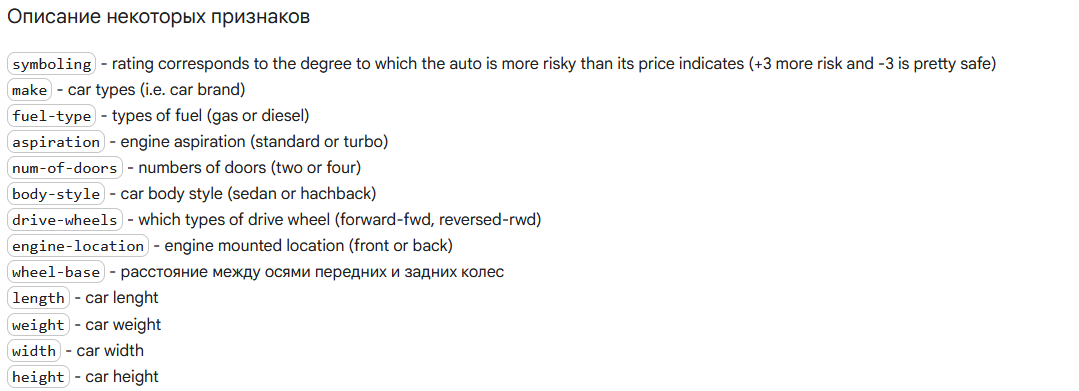

In [138]:
df.shape

(205, 26)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [206]:
# Пропуски в этом датасете обозначены как ?

for c in df.columns:
    print(c, len(df[df[c] == '?']))

for c in updated_df.columns:
    print(c, len(updated_df[updated_df[c] == '?']))

symboling 0
normalized-losses 37
make 0
fuel-type 0
aspiration 0
num-of-doors 0
body-style 0
drive-wheels 0
engine-location 0
wheel-base 0
length 0
width 0
height 0
curb-weight 0
engine-type 0
num-of-cylinders 0
engine-size 0
fuel-system 0
bore 0
stroke 0
compression-ratio 0
horsepower 0
peak-rpm 0
city-mpg 0
highway-mpg 0
price 0
symboling 0
normalized-losses 37
make 0
fuel-type 0
aspiration 0
num-of-doors 0
body-style 0
drive-wheels 0
engine-location 0
wheel-base 0
length 0
width 0
height 0
curb-weight 0
engine-type 0
num-of-cylinders 0
engine-size 0
fuel-system 0
bore 0
stroke 0
compression-ratio 0
horsepower 0
peak-rpm 0
city-mpg 0
highway-mpg 0
price 0


In [143]:
# Удалим строки, для которых неизвестно значение price, так как это целевая переменная

df = df[df['price'] != '?']

In [144]:
df.shape

(201, 26)

In [147]:
df.mean(numeric_only=True)

symboling               0.840796
wheel-base             98.797015
length                174.200995
width                  65.889055
height                 53.766667
curb-weight          2555.666667
engine-size           126.875622
compression-ratio      10.164279
city-mpg               25.179104
highway-mpg            30.686567
dtype: float64

In [193]:
# Чему равно среднее значение peak-rpm до заполнения пропусков?

df1 = df[df['peak-rpm'] != '?']
peak = df1['peak-rpm'].map(lambda x: int(x) if x != '?' else 0).mean()
peak

np.float64(5117.587939698493)

In [205]:
num_cols = df.columns[df.dtypes == 'int64'].tolist()
cat_cols = ['num-of-doors', 'bore', 'stroke', 'horsepower', 'peak-rpm']

updated_df = df.copy()

# Заполним средним значением пропуски в столбцах для числовых признаков

for cat in num_cols:
    mean = updated_df[cat].mean()
    updated_df[cat] = updated_df[cat].map(lambda x: mean if x == '?' else x)

# Заполним самым популярным значением для категориальных признаков

for cat in cat_cols:
    moda = df[cat][df[cat]!='?'].mode()[0]
    updated_df[cat] = updated_df[cat].map(lambda x: moda if x == '?' else x)

df = updated_df

In [197]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [208]:
# Пропуски в столбце normalized-losses предскажите при помощи линейной регрессии 
# по признакам symboling, wheel-base, length, width, height, curb-weight, engine-size, 
# compression-ratio, city-mpg, highway-mpg и заполните их предсказаниями

# Шаг 1 - поделим датасет на трейн (где значение в столбце normalized-losses есть) и на тест (где значения нет)

features = ['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg']

df_train = df[df['normalized-losses'] != '?']
X_train = df_train[features]
y_train = df_train['normalized-losses']

df_missing = df[df['normalized-losses'] == '?']
X_missing = df_missing[features]

In [209]:
# Шаг 2 - применяем линейную регрессию

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_missing = lr.predict(X_missing)
y_missing

array([168.07249262, 168.07249262, 134.0017988 , 150.03347669,
       124.36459916, 136.54127678, 127.28771126, 138.09039231,
       130.51306948, 113.6478041 , 155.82813541, 175.60424066,
       166.04457052,  88.0845543 , 122.53305095, 127.5822689 ,
       161.54047049, 154.33123955, 132.97923436, 178.13829126,
       179.87212963, 179.97064318, 131.27495017, 119.95762868,
       144.30448909, 121.04127767, 177.84275063, 157.63816248,
       157.63816248, 158.50508167,  98.29098277, 154.71344201,
       121.38477454, 137.06488059, 108.12442301,  94.62530543,
       106.22799742])

In [211]:
# Шаг 3 - соберем обратно датафрейм

fulfilled_df = df.copy()

indices = X_missing.index.to_numpy()

fulfilled_df.loc[indices, 'normalized-losses'] = y_missing

In [214]:
# Чему равно предсказание линейной регрессии на первом пропущенном значении? Ответ округлите до целого числа.

round(fulfilled_df['normalized-losses'][0])

168

In [216]:
# Закодируйте бинарные признаки fuel-type, aspiration, num-of-doors, engine-location каждый отдельной колонкой, 
# состоящей из 0 и 1. Единицей кодируйте самую частую категорию.

features = ['fuel-type', 'aspiration', 'num-of-doors', 'engine-location']
enc_df = fulfilled_df.copy()

for cat in features:
    counts = enc_df[cat].value_counts()
    moda = counts.idxmax()         
    other = counts.index[1] 
    enc_df[cat] = enc_df[cat].map({moda: 1, other: 0})

In [259]:
# Вынесите в переменную y целевую переменную price, а все остальные колонки - в матрицу X

X = enc_df.drop(['price'], axis = 1)
y = enc_df['price'].astype(float)

In [260]:
# Закодируйте признаки make, body-style, engine-type, fuel-system при помощи LeaveOneOutEncoder.

from category_encoders.leave_one_out import LeaveOneOutEncoder

features = ['make', 'body-style', 'engine-type', 'fuel-system']
loo_enc = LeaveOneOutEncoder(sigma = 0)

X[features] = loo_enc.fit_transform(X[features], y)

In [261]:
# Чему равно среднее значение в столбце body-style после кодирования? Ответ округлите до целого числа.

X['body-style'].mean()

np.float64(13207.129353233831)

In [264]:
# Закодируйте признак drive-wheels при помощи OHE из библиотеки category_encoders

from category_encoders.one_hot import OneHotEncoder

one_hot_enc = OneHotEncoder()

encoded = one_hot_enc.fit_transform(X[['drive-wheels']], drop = 'first')

X = X.drop(['drive-wheels'], axis = 1)

X = pd.concat([X, encoded], axis = 1)

In [266]:
X['num-of-cylinders'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [269]:
# В столбце num-of-cylinders категории упорядочены по смыслу. Закодируйте их подряд идущими числами, начиная с 1, согласно смыслу

dict_noc = {'two' : 1,
            'three' : 2,
            'four' :3,
            'five' : 4,
            'six' : 5,
            'eight' : 6,
            'twelve' : 7}

X['num-of-cylinders'] = X['num-of-cylinders'].map(lambda x: dict_noc[x])

In [271]:
X['normalized-losses'] = X['normalized-losses'].astype(float)
X['bore'] = X['bore'].astype(float)
X['stroke'] = X['stroke'].astype(float)
X['horsepower'] = X['horsepower'].astype(float)
X['peak-rpm'] = X['peak-rpm'].astype(float)

y = y.astype(float)

In [273]:
# Разбейте данные на тренировочную и тестовую часть в пропорции 3 к 1, зафиксируйте random_state = 42.

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.75, random_state = 42)

In [275]:
# Масштабируйте данные при помощи MinMaxScaler.
# Обучайте масштабирование на тренировочных данных, а потом примените и к трейну, и к тесту.

from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

mm.fit(Xtrain)

Xtrain = mm.transform(Xtrain)
Xtest = mm.transform(Xtest)

In [277]:
# Обучите на тренировочных данных линейную регрессию, сделайте предсказание на тесте и вычислите значение R2 на тестовых данных.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ll = LinearRegression()

ll.fit(Xtrain, ytrain)

pred = ll.predict(Xtest)

r2_ll = r2_score(ytest, pred)

print(r2_ll)

0.9065253713014978
